In [1]:
!pip install torch_geometric

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.3 MB/s eta 0:00:00
Mounted at /content/drive


# **1. 데이터셋 로드 및 분할**

In [2]:
import torch
import pickle
import numpy as np
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter


PROCESSED_DATA_PATH = '/content/drive/MyDrive/ACK2026_Wafer/Train_Model/Training_Data/final_training_data.pkl'

# ==========================================
# 📊 데이터셋 클래스 및 라벨 인코딩 정의
# ==========================================
# 8대 불량 패턴 라벨 인코딩
LABEL_MAP = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
    'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7
}
REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

class WaferDualTrackDataset(Dataset):
    def __init__(self, pkl_file):
        print(f"🔄 전처리 데이터 로드 중: {pkl_file}")
        with open(pkl_file, 'rb') as f:
            self.raw_data = pickle.load(f)

        self.data_list = []

        for item in self.raw_data:
            # 라벨 평탄화 (['Edge-Ring'] -> 'Edge-Ring')
            label_str = item['failureType']
            if isinstance(label_str, (list, np.ndarray)):
                label_str = label_str[0][0] if len(label_str) > 0 and isinstance(label_str[0], (list, np.ndarray)) else label_str[0]

            if label_str not in LABEL_MAP:
                continue

            y = torch.tensor([LABEL_MAP[label_str]], dtype=torch.long)

            # 극좌표 이미지를 텐서로 변환
            polar_img = item['polar_image']
            if not isinstance(polar_img, torch.Tensor):
                polar_img = torch.tensor(polar_img, dtype=torch.float32)

            # PyG Data 객체로 포장 (투 트랙 데이터 병합)
            data = Data(
                x=item['graph_x'],               # [Track 1] 노드 좌표
                edge_index=item['edge_index'],   # [Track 1] 엣지 연결 정보
                polar_image=polar_img,           # [Track 2] 극좌표계 2D 이미지
                y=y                              # 최종 정답 라벨
            )
            self.data_list.append(data)

        print(f"✅ 총 {len(self.data_list)}개의 투 트랙 데이터 준비 완료!\n")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

# ==========================================
# 🚀 실행 파트: 분할, 검증 및 데이터로더 생성
# ==========================================
if __name__ == "__main__":
    # 1. 데이터셋 인스턴스화
    dataset = WaferDualTrackDataset(PROCESSED_DATA_PATH)

    # 2. 클래스 불균형을 고려한 층화 표집(Stratified Split) 분할 (Train 80% / Test 20%)
    labels = [d.y.item() for d in dataset]
    train_data, val_data = train_test_split(
        dataset, test_size=0.2, stratify=labels, random_state=42
    )

    # 3. 🎯 [추가된 기능] 분할 결과 (8:2) 정밀 검증 출력
    train_counts = Counter([d.y.item() for d in train_data])
    val_counts = Counter([d.y.item() for d in val_data])

    print("=" * 60)
    print("📊 [분할 완료: Train vs Test(Val) 8:2 비율 검증]")
    print(f"전체 학습(Train) 데이터 개수: {len(train_data)}개")
    print(f"전체 평가(Test) 데이터 개수: {len(val_data)}개\n")

    print(f"{'결함 패턴':<12} | {'Train 개수':<10} | {'Test 개수':<10} | {'Train 비율(%)':<12}")
    print("-" * 60)
    for i in range(8):
        t_count = train_counts.get(i, 0)
        v_count = val_counts.get(i, 0)
        total = t_count + v_count
        t_ratio = (t_count / total * 100) if total > 0 else 0

        pattern_name = REVERSE_LABEL_MAP[i]
        print(f"{pattern_name:<12} | {t_count:<10} | {v_count:<10} | {t_ratio:.1f}%")
    print("=" * 60 + "\n")

    # 4. PyG DataLoader 생성 (Batch Size: 32)
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

    # 5. 첫 번째 배치(Batch) 추출 및 규격 확인
    for batch in train_loader:
        print("==== 📦 첫 번째 미니 배치(Batch) 구조 확인 ====")
        print(f"1) 배치 내 웨이퍼 맵 개수: {batch.num_graphs} 개 (Batch Size)")
        print(f"2) [GCN용] 누적 노드(x) 크기: {batch.x.shape}")
        print(f"3) [GCN용] 누적 엣지(edge_index) 크기: {batch.edge_index.shape}")
        print(f"4) [ResNet용] 극좌표 이미지 크기: {batch.polar_image.shape}")
        print(f"5) 정답 라벨(y) 크기: {batch.y.shape}")
        break

🔄 전처리 데이터 로드 중: /content/drive/MyDrive/ACK2026_Wafer/Train_Model/Training_Data/final_training_data.pkl
✅ 총 25519개의 투 트랙 데이터 준비 완료!

📊 [분할 완료: Train vs Test(Val) 8:2 비율 검증]
전체 학습(Train) 데이터 개수: 20415개
전체 평가(Test) 데이터 개수: 5104개

결함 패턴        | Train 개수   | Test 개수    | Train 비율(%) 
------------------------------------------------------------
Center       | 3435       | 859        | 80.0%
Donut        | 444        | 111        | 80.0%
Edge-Loc     | 4151       | 1038       | 80.0%
Edge-Ring    | 7744       | 1936       | 80.0%
Loc          | 2874       | 719        | 80.0%
Random       | 693        | 173        | 80.0%
Scratch      | 955        | 238        | 80.1%
Near-full    | 119        | 30         | 79.9%

==== 📦 첫 번째 미니 배치(Batch) 구조 확인 ====
1) 배치 내 웨이퍼 맵 개수: 32 개 (Batch Size)
2) [GCN용] 누적 노드(x) 크기: torch.Size([4982, 2])
3) [GCN용] 누적 엣지(edge_index) 크기: torch.Size([2, 33346])
4) [ResNet용] 극좌표 이미지 크기: torch.Size([32, 64, 64])
5) 정답 라벨(y) 크기: torch.Size([32])


# **2. GCN 모델 구축**

In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

# ==========================================
# 🧠 [Track 1] GCN 기반 형태 학습 네트워크 설계
# ==========================================
class WaferGCN(torch.nn.Module):
    def __init__(self, node_features=2, hidden_channels=64, out_channels=128):
        super(WaferGCN, self).__init__()
        # 입력 차원(node_features)은 2입니다. (전처리에서 추출한 X, Y 좌표)
        # out_channels(128)는 최종적으로 압축될 '형태 벡터'의 길이입니다.

        # 1. 3층 구조의 GCN (Graph Convolutional Network) 레이어
        # 노드들이 서로의 위치 정보를 3번에 걸쳐 폭넓게 교환하도록 설계합니다.
        self.conv1 = GCNConv(node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # x: 불량 칩들의 (X, Y) 좌표 [노드 수, 2]
        # edge_index: 불량 칩들 간의 연결선 정보 [2, 엣지 수]
        # batch: 각 노드가 32개의 웨이퍼 중 몇 번 웨이퍼 소속인지 알려주는 인덱스

        # --- 메시지 전달 (Message Passing) ---
        x = self.conv1(x, edge_index)
        x = F.relu(x) # 비선형성 추가

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        # (이 시점에서 x는 각 '결함 칩'의 고차원 특징을 담고 있습니다.)

        # --- 💡 판독 함수 (Readout Function) ---
        # 수천 개의 결함 칩 노드들을 웨이퍼(Batch) 단위로 묶어서 평균(Mean)을 냅니다.
        # 이 과정을 거치면 서로 다른 크기의 그래프들이 '웨이퍼당 1개의 고정된 벡터'로 압축됩니다.
        shape_vector = global_mean_pool(x, batch)

        return shape_vector

# ==========================================
# 🚀 2단계 코드 검증 (1단계의 Batch 데이터를 통과시켜 보기)
# ==========================================
if __name__ == "__main__":
    # 코랩 GPU 사용 가능 여부 확인
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️ 현재 사용 중인 연산 장치: {device}")

    # 1. 모델 인스턴스 생성 및 GPU 탑재
    # 최종적으로 128차원의 '형태 벡터'를 출력하도록 설정
    gcn_model = WaferGCN(node_features=2, hidden_channels=64, out_channels=128).to(device)

    # 2. 앞선 1단계에서 만든 데이터로더가 있다고 가정하고, 테스트 진행
    try:
        # train_loader에서 첫 번째 배치를 가져옵니다. (1단계 코드가 실행된 상태여야 함)
        test_batch = next(iter(train_loader)).to(device)

        # 3. 모델에 그래프 데이터 투입!
        shape_vector_output = gcn_model(test_batch.x, test_batch.edge_index, test_batch.batch)

        print("\n==== ✨ [Track 1] GCN 모델 통과 결과 ====")
        print(f"입력된 누적 노드 크기: {test_batch.x.shape}")
        print(f"입력된 누적 엣지 크기: {test_batch.edge_index.shape}")
        print(f"🎯 최종 출력된 '형태 벡터(Shape Vector)'의 크기: {shape_vector_output.shape}")
        print("-> 해석: 32장의 웨이퍼가 각각 128개의 숫자로 이루어진 '형태 특성'으로 완벽하게 압축되었습니다!")

    except NameError:
        print("\n🚨 train_loader가 메모리에 없습니다. 1단계 데이터셋 코드를 먼저 실행해 주세요.")

🖥️ 현재 사용 중인 연산 장치: cuda

==== ✨ [Track 1] GCN 모델 통과 결과 ====
입력된 누적 노드 크기: torch.Size([7477, 2])
입력된 누적 엣지 크기: torch.Size([2, 133944])
🎯 최종 출력된 '형태 벡터(Shape Vector)'의 크기: torch.Size([32, 128])
-> 해석: 32장의 웨이퍼가 각각 128개의 숫자로 이루어진 '형태 특성'으로 완벽하게 압축되었습니다!


# **3. ResNet 모델 구축**

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models

# ==========================================
# 👁️ [Track 2] 극좌표계 ResNet 위치 학습 네트워크 설계
# ==========================================
class PolarResNet(nn.Module):
    def __init__(self, out_channels=128):
        super(PolarResNet, self).__init__()

        # 1. 뼈대가 될 가벼운 ResNet-18 모델을 불러옵니다.
        # (웨이퍼 이미지는 일반 사물 사진과 다르므로 사전학습 가중치 없이 빈 뇌 상태로 시작)
        self.resnet = models.resnet18(weights=None)

        # 2. [핵심 개조 1] 첫 번째 합성곱 층(Conv1)을 1채널(흑백) 입력용으로 교체
        # 원래 구조: nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # 3. [핵심 개조 2] 마지막 완전연결계층(FC)을 우리의 '위치 벡터' 크기(128)에 맞게 교체
        num_features = self.resnet.fc.in_features  # 보통 ResNet-18은 512입니다.
        self.resnet.fc = nn.Linear(num_features, out_channels)

    def forward(self, x):
        # x: 극좌표계 이미지 텐서
        # 주의: 1단계 데이터로더에서 넘어온 이미지는 [32, 64, 64] 형태입니다.
        # CNN은 반드시 [배치, 채널, 높이, 너비]를 요구하므로 채널 차원(1)을 억지로 끼워 넣습니다.
        if x.dim() == 3:
            x = x.unsqueeze(1) # [32, 64, 64] -> [32, 1, 64, 64]

        # ResNet 통과!
        position_vector = self.resnet(x)

        return position_vector

# ==========================================
# 🚀 3단계 코드 검증 (1단계의 Batch 데이터를 통과시켜 보기)
# ==========================================
if __name__ == "__main__":
    # 코랩 GPU 사용 가능 여부 확인
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 모델 인스턴스 생성 및 GPU 탑재
    # GCN과 마찬가지로 128차원의 '위치 벡터'를 출력하도록 설정
    resnet_model = PolarResNet(out_channels=128).to(device)

    try:
        # 1단계의 데이터로더가 메모리에 살아있다고 가정하고 첫 번째 배치 추출
        test_batch = next(iter(train_loader)).to(device)

        # 2. 극좌표계 이미지를 ResNet 모델에 투입!
        position_vector_output = resnet_model(test_batch.polar_image)

        print("\n==== ✨ [Track 2] 극좌표계 ResNet 모델 통과 결과 ====")
        print(f"입력된 극좌표 이미지 초기 크기: {test_batch.polar_image.shape}")
        # 내부적으로 unsqueeze를 거쳐 [32, 1, 64, 64]로 변환된 후 처리됩니다.
        print(f"🎯 최종 출력된 '위치 벡터(Position Vector)'의 크기: {position_vector_output.shape}")
        print("-> 해석: 32장의 극좌표 웨이퍼 맵이 각각 128개의 숫자로 이루어진 '공간적 위치 특성'으로 완벽하게 추출되었습니다!")

    except NameError:
        print("\n🚨 train_loader가 메모리에 없습니다. 1단계 데이터셋 코드를 먼저 실행해 주세요.")


==== ✨ [Track 2] 극좌표계 ResNet 모델 통과 결과 ====
입력된 극좌표 이미지 초기 크기: torch.Size([32, 64, 64])
🎯 최종 출력된 '위치 벡터(Position Vector)'의 크기: torch.Size([32, 128])
-> 해석: 32장의 극좌표 웨이퍼 맵이 각각 128개의 숫자로 이루어진 '공간적 위치 특성'으로 완벽하게 추출되었습니다!


# **4. 모델 융합**

In [5]:
import torch
import torch.nn as nn

# ==========================================
# 🧠+👁️ [4단계] 투 트랙 융합 모델 (Dual-Track Fusion Model)
# ==========================================
class DualTrackFusionModel(nn.Module):
    def __init__(self, num_classes=8):
        super(DualTrackFusionModel, self).__init__()

        # 1. 두 개의 독립적인 네트워크(두뇌) 장착
        self.track1_gcn = WaferGCN(node_features=2, hidden_channels=64, out_channels=128)
        self.track2_resnet = PolarResNet(out_channels=128)

        # 2. 분류기(Classifier) 조립
        # 입력 차원: GCN 출력(128) + ResNet 출력(128) = 총 256차원
        # 출력 차원: 우리의 타겟 불량 패턴 개수인 8차원
        self.classifier = nn.Sequential(
            nn.Linear(128 + 128, 128),  # 256차원 -> 128차원으로 압축
            nn.ReLU(),                  # 활성화 함수
            nn.Dropout(0.5),            # 과적합 방지 (기억력 일부를 일부러 끄는 기법)
            nn.Linear(128, num_classes) # 최종 8개 패턴에 대한 예측값(Logits) 출력
        )

    def forward(self, x, edge_index, batch, polar_image):
        # [Step A] 각 트랙에 데이터 통과
        shape_vector = self.track1_gcn(x, edge_index, batch)      # 형태 특성 추출 [Batch, 128]
        position_vector = self.track2_resnet(polar_image)         # 위치 특성 추출 [Batch, 128]

        # [Step B] 특징 융합 (Feature Fusion)
        # dim=1을 기준으로 가로로 이어 붙입니다.
        fused_vector = torch.cat([shape_vector, position_vector], dim=1) # [Batch, 256]

        # [Step C] 최종 분류
        logits = self.classifier(fused_vector)                    # [Batch, 8]

        return logits

# ==========================================
# 🚀 4단계 통합 모델 테스트 (최종 출력 확인)
# ==========================================
if __name__ == "__main__":
    # 장치 설정
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 통합 모델 생성 및 GPU 탑재
    fusion_model = DualTrackFusionModel(num_classes=8).to(device)

    try:
        # 1단계의 데이터로더에서 배치 하나 추출
        test_batch = next(iter(train_loader)).to(device)

        # 통합 모델에 모든 데이터(그래프 + 이미지)를 한 번에 투입!
        final_output = fusion_model(
            test_batch.x,
            test_batch.edge_index,
            test_batch.batch,
            test_batch.polar_image
        )

        print("\n==== 🎯 [Step 4] 통합 모델 최종 통과 결과 ====")
        print(f"최종 출력 텐서의 크기: {final_output.shape}")
        print("-> 해석: 32장의 웨이퍼에 대해 각각 8가지 불량 패턴의 '예측 확률 점수'가 도출되었습니다!")

        # 첫 번째 웨이퍼의 8개 클래스 점수 확인
        print(f"\n[참고] 첫 번째 웨이퍼의 8개 패턴별 예측 점수(Logits):\n{final_output[0].detach().cpu().numpy()}")

    except NameError:
        print("\n🚨 train_loader가 메모리에 없습니다. 1단계 데이터셋 코드를 다시 실행해 주세요.")


==== 🎯 [Step 4] 통합 모델 최종 통과 결과 ====
최종 출력 텐서의 크기: torch.Size([32, 8])
-> 해석: 32장의 웨이퍼에 대해 각각 8가지 불량 패턴의 '예측 확률 점수'가 도출되었습니다!

[참고] 첫 번째 웨이퍼의 8개 패턴별 예측 점수(Logits):
[-0.12372442 -0.41513425 -0.09844087 -0.03648831 -0.10684655 -0.32540306
 -0.16390567  0.16117793]


# **5. 학습 및 추론**

🔄 클래스 가중치(Class Weights) 계산 중...
✅ 클래스별 페널티 가중치 설정 완료!

🔄 모델과 옵티마이저를 초기화하고 100 Epoch 풀(Full) 학습을 준비합니다...
🔥 100 Epoch 대장정을 시작합니다! (최고 성능 달성 시 자동 저장) 🔥

Epoch [  1/100] | Train Loss: 1.0243 | Val Loss: 0.8344 | Val Macro F1: 0.5581 ⭐ (Best Model Saved!)
Epoch [  2/100] | Train Loss: 0.7239 | Val Loss: 0.7876 | Val Macro F1: 0.6684 ⭐ (Best Model Saved!)
Epoch [  3/100] | Train Loss: 0.6333 | Val Loss: 0.5665 | Val Macro F1: 0.6700 ⭐ (Best Model Saved!)
Epoch [  4/100] | Train Loss: 0.5501 | Val Loss: 0.5687 | Val Macro F1: 0.7610 ⭐ (Best Model Saved!)
Epoch [  6/100] | Train Loss: 0.4051 | Val Loss: 0.5807 | Val Macro F1: 0.7875 ⭐ (Best Model Saved!)
Epoch [  9/100] | Train Loss: 0.3232 | Val Loss: 0.5008 | Val Macro F1: 0.8066 ⭐ (Best Model Saved!)
Epoch [ 10/100] | Train Loss: 0.2800 | Val Loss: 0.4830 | Val Macro F1: 0.8312 ⭐ (Best Model Saved!)
Epoch [ 11/100] | Train Loss: 0.2879 | Val Loss: 0.5216 | Val Macro F1: 0.8316 ⭐ (Best Model Saved!)
Epoch [ 14/100] | Train Loss: 0.1887 | V

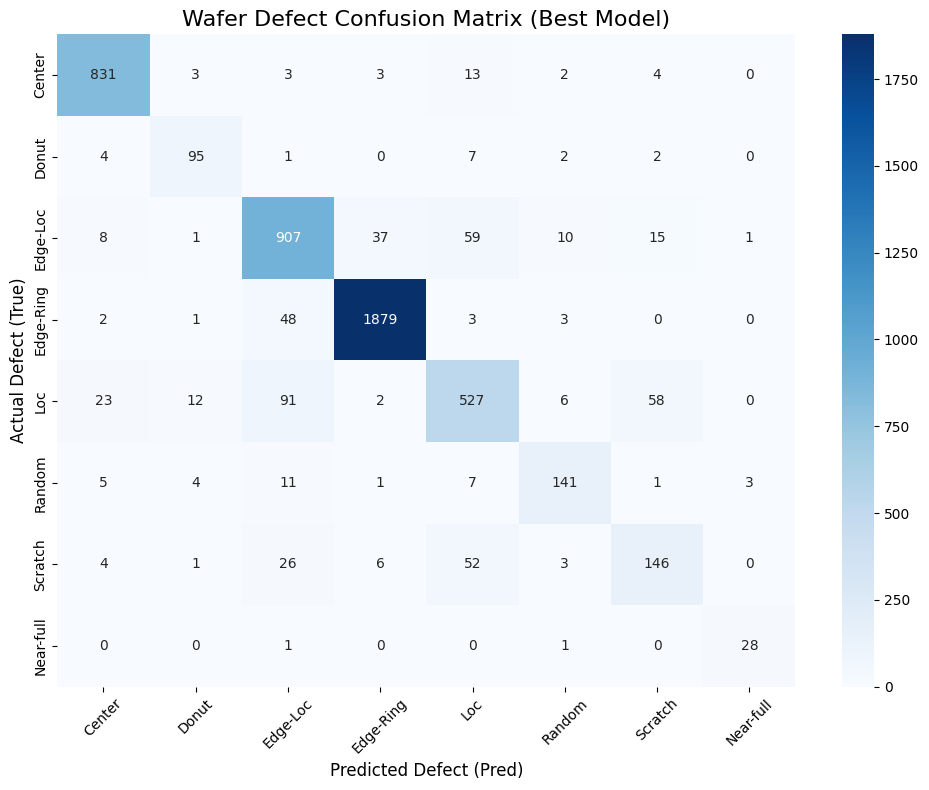

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ==========================================
# 🛡️ [Step 5-1] 클래스 불균형 방어 (Class Weights 계산)
# ==========================================
print("🔄 클래스 가중치(Class Weights) 계산 중...")

# 1단계에서 만들어둔 train_data에서 라벨만 추출
train_labels = [d.y.item() for d in train_data]

# sklearn을 이용해 데이터가 적을수록 높은 가중치를 갖도록 자동 계산 ('balanced')
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
weights_tensor = torch.tensor(computed_weights, dtype=torch.float32).to(device)

print("✅ 클래스별 페널티 가중치 설정 완료!\n")

# ==========================================
# ⚙️ [Step 5-2] 모델 초기화 및 학습 세팅 (100 Epoch 새 출발)
# ==========================================
print("🔄 모델과 옵티마이저를 초기화하고 100 Epoch 풀(Full) 학습을 준비합니다...")

# 모델을 초기 상태로 새로 생성 (이전 학습 기억 지우기)
fusion_model = DualTrackFusionModel(num_classes=8).to(device)

# 가중치가 적용된 크로스 엔트로피 손실 함수
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Adam 옵티마이저 (학습률 0.001)
optimizer = optim.Adam(fusion_model.parameters(), lr=0.001)

# 최우수 모델 저장을 위한 변수 세팅
best_val_f1 = 0.0
BEST_MODEL_PATH = '/content/drive/MyDrive/ACK2026_Wafer/Train_Model/best_wafer_fusion_model.pth'
EPOCHS = 100

print("🔥 100 Epoch 대장정을 시작합니다! (최고 성능 달성 시 자동 저장) 🔥\n")

# ==========================================
# 🚀 [Step 5-3] 100 Epoch 본 학습 루프 (Training Loop)
# ==========================================
for epoch in range(EPOCHS):
    # --- Training ---
    fusion_model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        outputs = fusion_model(batch.x, batch.edge_index, batch.batch, batch.polar_image)
        loss = criterion(outputs, batch.y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch.num_graphs

    train_loss /= len(train_loader.dataset)

    # --- Validation ---
    fusion_model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            outputs = fusion_model(batch.x, batch.edge_index, batch.batch, batch.polar_image)
            loss = criterion(outputs, batch.y)

            val_loss += loss.item() * batch.num_graphs
            preds = outputs.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    # 🌟 [핵심] 최고 성능 달성 시 모델 자동 저장
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(fusion_model.state_dict(), BEST_MODEL_PATH)
        mark = "⭐ (Best Model Saved!)"
    else:
        mark = ""

    # 10번마다 한 번씩 출력 (Best 갱신 시에는 항상 출력)
    if (epoch + 1) % 10 == 0 or val_f1 == best_val_f1:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f} {mark}")

print(f"\n🎉 100 Epoch 학습 완료! 가장 높았던 Macro F1 점수: {best_val_f1:.4f}")

# ==========================================
# 📊 [Step 5-4] 최고 성능 모델 로드 및 최종 추론 (Inference)
# ==========================================
print("\n🔍 저장된 최고의 모델을 불러와 최종 평가를 진행합니다...")
fusion_model.load_state_dict(torch.load(BEST_MODEL_PATH))
fusion_model.eval()

final_preds, final_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        outputs = fusion_model(batch.x, batch.edge_index, batch.batch, batch.polar_image)
        final_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        final_labels.extend(batch.y.cpu().numpy())

# 라벨 이름 리스트 (0~7 순서대로 매핑)
target_names = [REVERSE_LABEL_MAP[i] for i in range(8)]

# ==========================================
# 📈 [Step 5-5] 결과 시각화 (Confusion Matrix & Report)
# ==========================================
print("\n" + "="*55)
print("📝 [최종 성적표] 클래스별 상세 F1-Score 리포트")
print("="*55)
print(classification_report(final_labels, final_preds, target_names=target_names, digits=4))

# 혼동 행렬 시각화 (Seaborn Heatmap)
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Wafer Defect Confusion Matrix (Best Model)', fontsize=16)
plt.ylabel('Actual Defect (True)', fontsize=12)
plt.xlabel('Predicted Defect (Pred)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()